In [1]:
import os
import sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, ROOT)
print(ROOT)

c:\Users\souza\OneDrive\Área de Trabalho\modelagem inadimplencia


In [2]:
import pandas as pd 
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils.analytics.MonteCarlo import MonteCarlo
#from utils.analytics.Plot3d import Plot3d

In [3]:
# funçao de diferença logaritmica
def log_diff(X:pd.Series):
    return np.log(X).diff()

In [4]:
x_train_path = os.path.join('..','..', 'data', 'processed', 'dados_treino.csv')
X_train = pd.read_csv(x_train_path)
X_train.shape

(166, 7)

In [5]:
# vetor resposta 
y_train_path = os.path.join('..', '..','data', 'processed', 'vetor_resposta.csv')
y_train = pd.read_csv(y_train_path)
y_train = y_train.set_index('data')
y_train

,Inadimplencia_PF
data,
2012-03-01,5.36
2012-04-01,5.41
2012-05-01,5.51
2012-06-01,5.43
2012-07-01,5.42
...,...
2025-09-01,4.89
2025-10-01,4.99
2025-11-01,5.12


In [6]:
X_train = X_train.dropna()

In [7]:
X_train.isnull().sum()

intercepto                    0
Confiança_consumidor          0
Desemprego                    0
SELIC                         0
IBC-Br                        0
IPCA                          0
Endividamento_das_familias    0
dtype: int64

In [8]:
X_train = X_train.dropna()
X_train

,intercepto,Confiança_consumidor,Desemprego,SELIC,IBC-Br,IPCA,Endividamento_das_familias
0,1,0.024095,7.366499,0.741320,0.003247,0.527917,37.111279
1,1,0.040457,7.443742,0.734245,0.012553,0.454032,37.259476
2,1,-0.017547,7.412833,0.659889,0.007148,0.285128,37.425464
3,1,0.010836,7.332529,0.621403,0.001709,0.689960,37.483668
4,1,-0.029887,7.280069,0.674989,0.002983,0.656219,37.587446
...,...,...,...,...,...,...,...
161,1,-0.014982,5.755866,1.221394,-0.001507,0.478253,49.138474
162,1,0.028579,5.654327,1.224007,0.000731,0.116143,49.388298
163,1,0.026956,5.515957,1.142840,0.005121,0.219613,49.537583
164,1,0.017922,5.372552,1.209036,0.001313,0.226347,49.701265


In [9]:
# criando funçao para previsao direta do modelo
def model_MQO(X:pd.DataFrame):
    return 8.025793 +  1.721968 *X['Confiança_consumidor'] + -0.149354 *X['Desemprego'] + 0.240921*X['SELIC'] + 2.644685 *X['IBC-Br'] + -0.240376*X['IPCA'] + -0.063539 *X['Endividamento_das_familias']

In [10]:
# fazendo previsoes
y_pred_train = model_MQO(X_train)


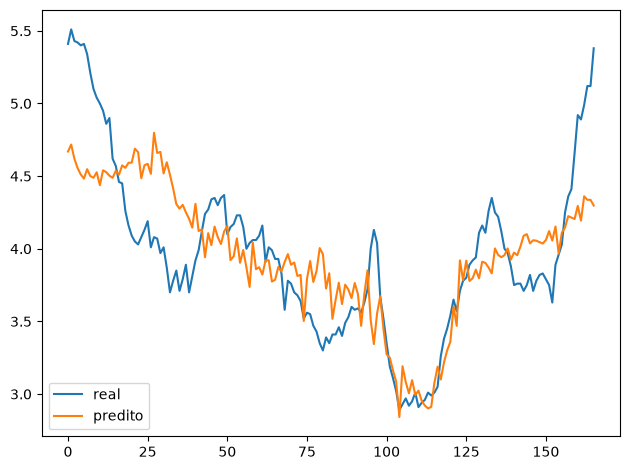

In [11]:
y_train_alinhado = y_train.iloc[-len(y_pred_train):]
y_train_alinhado = y_train_alinhado.squeeze()
y_train_alinhado = y_train_alinhado.reset_index(drop=True)
y_train_alinhado = pd.Series(y_train_alinhado)
plt.plot(X_train.index, y_train_alinhado, label='real')
plt.plot(X_train.index, y_pred_train, label='predito')
plt.tight_layout()
plt.legend()
plt.show()

In [12]:
resid = y_train_alinhado - y_pred_train

In [13]:
print(f'média dos residuos: {resid.mean()}')
print()
print(f'desvio padrao: {resid.std()}')

média dos residuos: 0.0050925310273928215

desvio padrao: 0.38477756698843774


# Aplicando estresses ao modelo 

In [26]:
def monte_carlo_plot(sim:pd.DataFrame, nsim:int):
    plt.figure(figsize=(12,8))
    sim_list = []
    for _ in range(nsim):
        pred = model_MQO(sim)
        y_hat = np.cumsum(pred)/np.arange(len(pred))
        y_hat = pd.Series(y_hat)
        sim_list.append(y_hat)
        plt.plot(y_hat)
    return y_hat

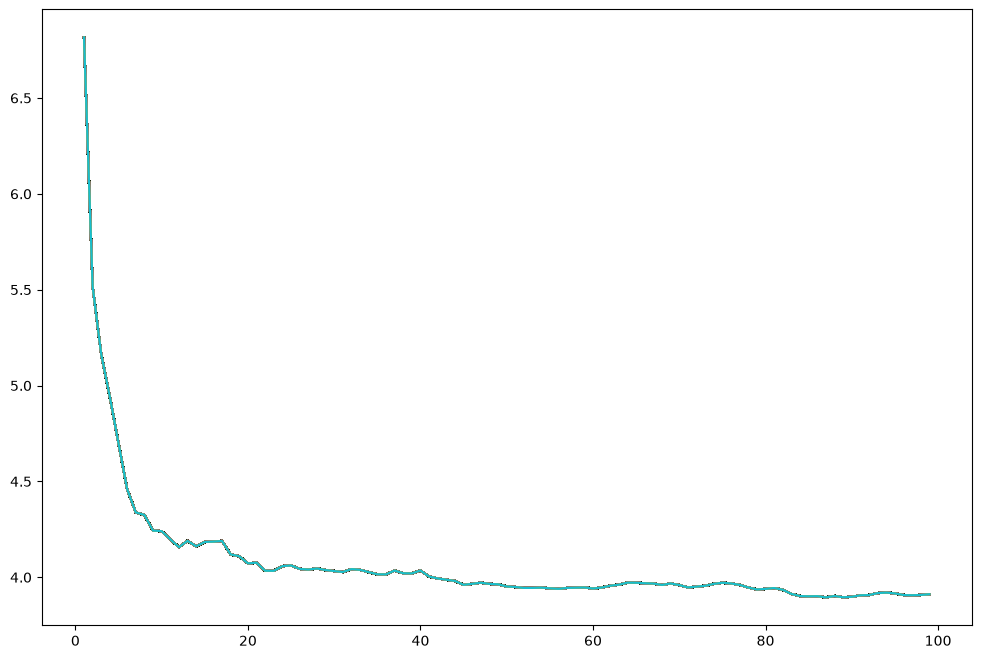

In [29]:
mc_sim = MonteCarlo(X_train)
mc_normal = mc_sim.normal_scenario(100)
y_hat = monte_carlo_plot(mc_normal, 1000)


In [30]:
# tirando o infinito 
normal_list = pd.concat([y_hat], axis=1)
normal_list = normal_list.replace(np.inf,0)


In [69]:
def RiskBands(y:pd.Series):
    y = y.replace(np.inf, 0)
    band = f"""
    Media das previsoes: {np.mean(y)}
    
    Desvio padrão: {np.std(y)}
    
    
    50%: {np.percentile(y, 50)}
    25%: {np.percentile(y, 75)}
    10%: {np.percentile(y, 90)}
    5%: {np.percentile(y, 95)}

    """

    return band

In [70]:
print(RiskBands(normal_list))


    Media das previsoes: 4.03706246550626

    Desvio padrão: 0.5467546679305224


    50%: 3.967822372797059
    25%: 4.042910992230591
    10%: 4.2026332418503545
    5%: 4.4723314269022705

    


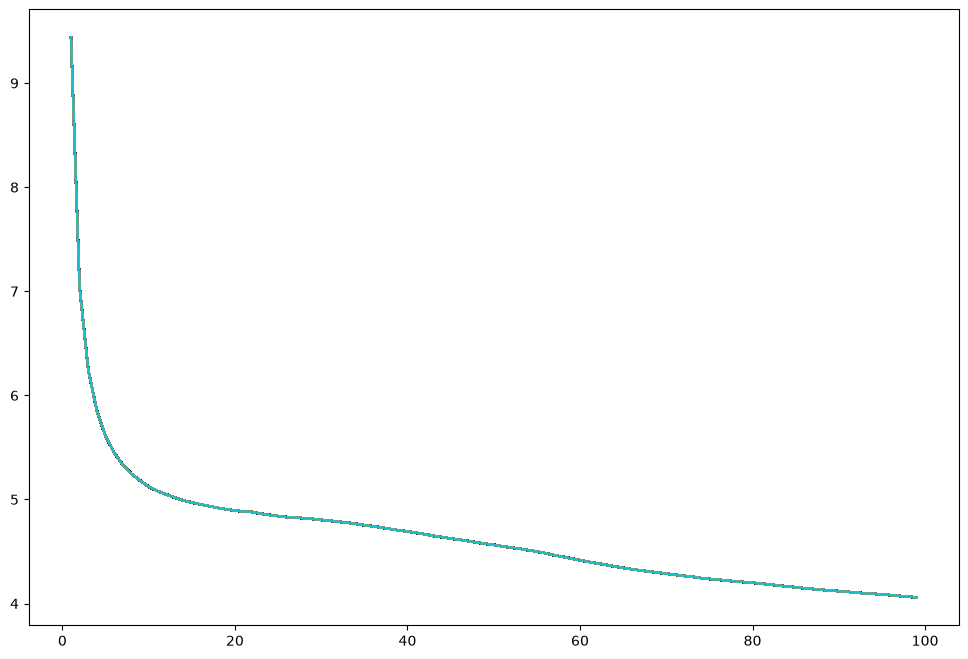

In [71]:
X_low_ibc = X_train.copy()
X_low_ibc['IBC-Br'] = mc_sim.T_student_shocks(100, 0.2, 'IBC-Br')
X_low_ibc = X_low_ibc.dropna()
y_ibc = monte_carlo_plot(X_low_ibc, 1000)


In [72]:
print(RiskBands(y_ibc))


    Media das previsoes: 4.6122743020837484

    Desvio padrão: 0.8177476341532921


    50%: 4.557029072381622
    25%: 4.83280276213757
    10%: 5.086031257973853
    5%: 5.4581636666526485

    
